Found 22048 images belonging to 2 classes.
Found 5510 images belonging to 2 classes.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 287s 414ms/step - accuracy: 0.6736 - loss: 0.6082 - val_accuracy: 0.8336 - val_loss: 0.4522
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 280s 406ms/step - accuracy: 0.8631 - loss: 0.3515 - val_accuracy: 0.9100 - val_loss: 0.2319
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 231s 335ms/step - accuracy: 0.9213 - loss: 0.2263 - val_accuracy: 0.9332 - val_loss: 0.1933
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 258s 374ms/step - accuracy: 0.9328 - loss: 0.1994 - val_accuracy: 0.9365 - val_loss: 0.1933
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 198s 287ms/step - accuracy: 0.9407 - loss: 0.1860 - val_accuracy: 0.9298 - val_loss: 0.1943
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 175s 254ms/step - accuracy: 0.9462 - loss: 0.1769 - val_accuracy: 0.9318 - val_loss: 0.1759
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 201s 291ms/step - accuracy: 0.9456 - loss: 0.1681 - val_accuracy: 0.9341 - val_loss: 0.1701
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 395s 573ms/step - accuracy: 0.9499 -


✅ Model saved as malaria_detector.h5


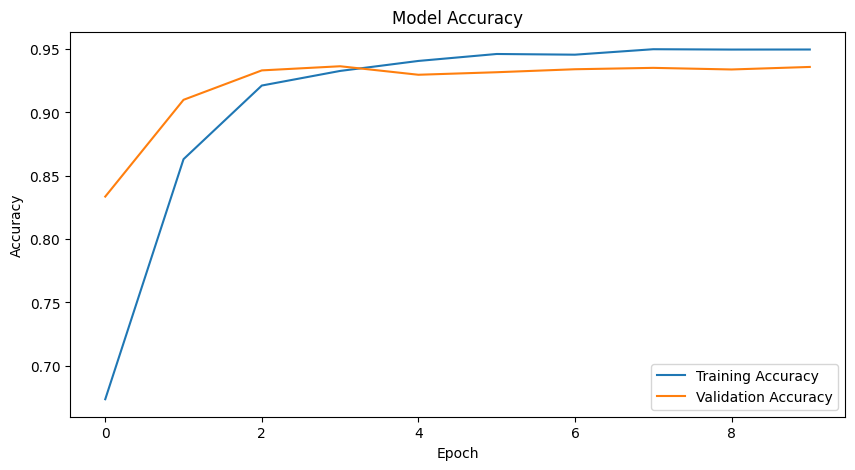

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step

✅ RESULT: UNINFECTED CELL
Probability of Malaria: 0.00%



In [1]:
# =========================================================
# MALARIA IMAGE RECOGNITION MODEL
# =========================================================
# Dataset:
# https://www.kaggle.com/datasets/iarunava/cell-images-for-detecting-malaria
#
# Folder Structure:
#
# cell_images/
# ├── Parasitized/
# └── Uninfected/
#
# =========================================================

import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

# =========================================================
# DATASET PATH
# =========================================================

dataset_path = "cell_images/"

# =========================================================
# IMAGE PREPROCESSING
# =========================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Training Data
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation Data
validation_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

# =========================================================
# BUILD CNN MODEL
# =========================================================

model = Sequential([

    # Input Layer
    Input(shape=(128, 128, 3)),

    # =====================================================
    # FIRST CONVOLUTION BLOCK
    # =====================================================
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # =====================================================
    # SECOND CONVOLUTION BLOCK
    # =====================================================
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # =====================================================
    # THIRD CONVOLUTION BLOCK
    # =====================================================
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # =====================================================
    # FLATTEN
    # =====================================================
    Flatten(),

    # =====================================================
    # DENSE LAYERS
    # =====================================================
    Dense(128, activation='relu'),
    Dropout(0.5),

    # =====================================================
    # OUTPUT LAYER
    # =====================================================
    Dense(1, activation='sigmoid')
])

# =========================================================
# COMPILE MODEL
# =========================================================

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# =========================================================
# MODEL SUMMARY
# =========================================================

model.summary()

# =========================================================
# TRAIN MODEL
# =========================================================

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

# =========================================================
# SAVE MODEL
# =========================================================

model.save("malaria_detector.h5")

print("\n✅ Model saved as malaria_detector.h5")

# =========================================================
# PLOT TRAINING RESULTS
# =========================================================

# Accuracy Plot
plt.figure(figsize=(10, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# =========================================================
# PREDICTION FUNCTION
# =========================================================

def predict_malaria(img_path):

    # Load Saved Model
    model = load_model("malaria_detector.h5")

    # Load Image
    img = image.load_img(img_path, target_size=(128, 128))

    # Convert Image to Array
    img_array = image.img_to_array(img)

    # Normalize
    img_array = img_array / 255.0

    # Expand Dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # Prediction
    prediction = model.predict(img_array)[0][0]

    # Probability
    probability = prediction * 100

    print("\n==============================")

    if prediction > 0.5:

        print("🦠 RESULT: MALARIA DETECTED")
        print(f"Probability: {probability:.2f}%")

        print("\nPossible Symptoms:")
        print("- Fever")
        print("- Chills")
        print("- Sweating")
        print("- Headache")
        print("- Fatigue")
        print("- Organ damage if untreated")

    else:

        print("✅ RESULT: UNINFECTED CELL")
        print(f"Probability of Malaria: {probability:.2f}%")

    print("==============================\n")

# =========================================================
# TEST IMAGE
# =========================================================

# Put your test image here
test_image_path = "cell_images/Parasitized/C39P4thinF_original_IMG_20150622_105102_cell_83.png"

# Predict
predict_malaria(test_image_path)

In [2]:
model.save("malaria_detector.keras")

In [3]:
model = load_model("malaria_detector.keras")

C:\Users\shawn\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\saving\saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
from tensorflow.keras.models import load_model

model = load_model(
    "malaria_detector.keras",
    compile=False
)

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

# ==========================================
# LOAD TRAINED MODEL
# ==========================================

model = load_model(
    "malaria_detector.keras",
    compile=False
)

# ==========================================
# IMAGE PATH
# ==========================================

img_path = "cell_images/Uninfected/C1_thinF_IMG_20150604_104919_cell_183.png"

# ==========================================
# LOAD IMAGE
# ==========================================

img = image.load_img(
    img_path,
    target_size=(128, 128)
)

# ==========================================
# CONVERT IMAGE TO ARRAY
# ==========================================

img_array = image.img_to_array(img)

# ==========================================
# NORMALIZE IMAGE
# ==========================================

img_array = img_array / 255.0

# ==========================================
# ADD BATCH DIMENSION
# ==========================================

img_array = np.expand_dims(img_array, axis=0)

# ==========================================
# PREDICT
# ==========================================

prediction = model.predict(img_array)[0][0]

# ==========================================
# SHOW RESULT
# ==========================================

if prediction < 0.5:

    print("🦠 MALARIA DETECTED")
    print(f"Probability: {(1 - prediction) * 100:.2f}%")

else:

    print("✅ UNINFECTED CELL")
    print(f"Confidence: {prediction * 100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
🦠 MALARIA DETECTED
Probability: 97.48%
